In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_core.prompts import PromptTemplate

/home/narendra/Agentic AI/agentenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    six: int
    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [3]:
def calculate_Sr(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    balls = state["balls"]

    sr = (runs / balls) * 100

    return {"sr": sr}

In [4]:
def calculate_bpb(state: BatsmanState) -> BatsmanState:
    fours = state["fours"]
    six = state["six"]
    balls = state["balls"]

    bpb = balls / (fours + six)

    return {"bpb": bpb}

In [5]:
def calculate_boundary_percent(state: BatsmanState) -> BatsmanState:

    fours = state["fours"]
    six = state["six"]
    runs = state["runs"]

    boundary_percent = ((fours * 4 + six * 6) / runs) * 100

    return {"boundary_percent": boundary_percent}

In [6]:
def summary(state: BatsmanState) -> BatsmanState:

    boundary_percent = state["boundary_percent"]
    bpb = state["bpb"]
    sr = state["sr"]

    message = f"batsman stike rate is : {sr}, \n  ball per boundary is  {bpb}, \n   boundary_percent is {boundary_percent}"

    return {"summary": message}

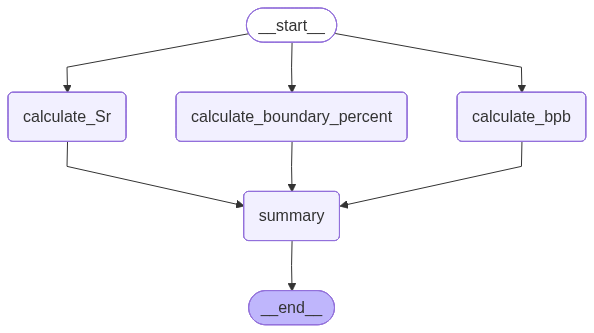

In [7]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_Sr", calculate_Sr)
graph.add_node("calculate_bpb", calculate_bpb)
graph.add_node("calculate_boundary_percent", calculate_boundary_percent)
graph.add_node("summary", summary)

graph.add_edge(START, "calculate_bpb")
graph.add_edge(START, "calculate_boundary_percent")
graph.add_edge(START, "calculate_Sr")

graph.add_edge("calculate_Sr", "summary")
graph.add_edge("calculate_bpb", "summary")
graph.add_edge("calculate_boundary_percent", "summary")

graph.add_edge("summary", END)

workflow = graph.compile()

workflow

In [8]:
input_State = {"runs": 100, "balls": 40, "fours": 4, "six": 8}
final_State = workflow.invoke(input_State)

final_State

{'runs': 100,
 'balls': 40,
 'fours': 4,
 'six': 8,
 'sr': 250.0,
 'bpb': 3.3333333333333335,
 'boundary_percent': 64.0,
 'summary': 'batsman stike rate is : 250.0, \n  ball per boundary is  3.3333333333333335, \n   boundary_percent is 64.0'}